<a href="https://colab.research.google.com/github/BryanHinostroza/lab06-bh/blob/develop/Lab06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio - Clasificación con k-NN y SMOTE (Breast Cancer Dataset)


Paso 1: Cargar y preparar los datos

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
# Cargar datos desde UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
columnas = ['ID', 'ClumpThickness', 'UniformityCellSize', 'UniformityCellShape',
            'MarginalAdhesion', 'SingleEpithelialCellSize', 'BareNuclei',
            'BlandChromatin', 'NormalNucleoli', 'Mitoses', 'Class']
data = pd.read_csv(url, names=columnas)

In [3]:
# Reemplazar los signos '?' por NaN y convertir a números
data['BareNuclei'].replace('?', np.nan, inplace=True)
data['BareNuclei'] = pd.to_numeric(data['BareNuclei'])


<ipython-input-3-40430c72be80>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['BareNuclei'].replace('?', np.nan, inplace=True)


In [4]:
# Imputación de valores nulos
data.fillna(data.median(), inplace=True)

In [5]:
# Eliminar columna 'ID'
data.drop('ID', axis=1, inplace=True)

In [6]:
# Separar variables predictoras y la variable objetivo
X = data.drop('Class', axis=1)
y = data['Class']

In [7]:
# Convertir etiquetas: 2 = Benigno, 4 = Maligno
y = y.map({2: 0, 4: 1}).astype(int)

In [8]:
# Separar datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Paso 2: Modelo k-NN y elección del número de vecinos óptimo

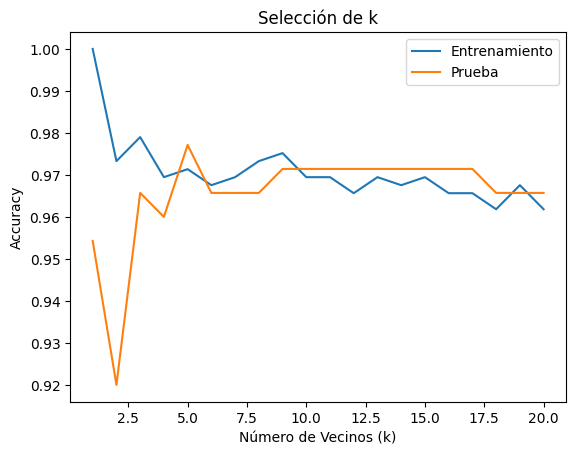

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

train_acc = []
test_acc = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_acc.append(knn.score(X_train, y_train))
    test_acc.append(knn.score(X_test, y_test))

plt.plot(range(1, 21), train_acc, label='Entrenamiento')
plt.plot(range(1, 21), test_acc, label='Prueba')
plt.xlabel('Número de Vecinos (k)')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Selección de k')
plt.show()


Paso 3: Métricas de evaluación del modelo

Matriz de Confusión:
 [[116   2]
 [  2  55]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       118
           1       0.96      0.96      0.96        57

    accuracy                           0.98       175
   macro avg       0.97      0.97      0.97       175
weighted avg       0.98      0.98      0.98       175



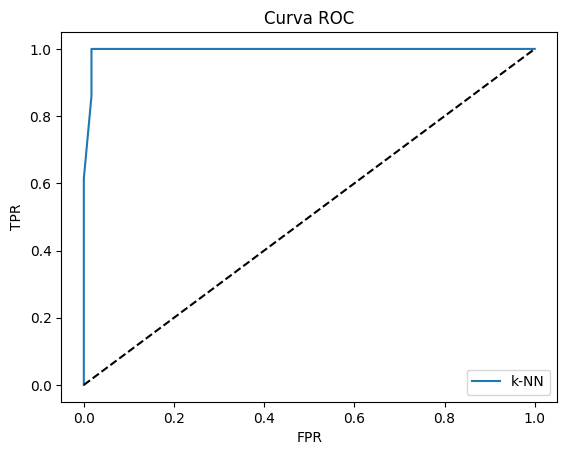

AUC: 0.9955 - Gini: 0.9911


In [10]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns

# Modelo con k óptimo (ej. 5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

# Curva ROC
y_prob = knn.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label='k-NN')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC')
plt.legend()
plt.show()

# AUC y Gini
auc = roc_auc_score(y_test, y_prob)
gini = 2 * auc - 1
print(f"AUC: {auc:.4f} - Gini: {gini:.4f}")


Paso 4: Balanceo de clases con SMOTE y comparación

In [11]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Aplicar SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print("Distribución después del SMOTE:", Counter(y_res))

#
knn_smote = KNeighborsClassifier(n_neighbors=5)
knn_smote.fit(X_res, y_res)
y_pred_smote = knn_smote.predict(X_test)

# Métricas
print("Matriz de Confusión con SMOTE:\n", confusion_matrix(y_test, y_pred_smote))
print("\nReporte de Clasificación con SMOTE:\n", classification_report(y_test, y_pred_smote))

# AUC y Gini con SMOTE
y_prob_smote = knn_smote.predict_proba(X_test)[:, 1]
auc_smote = roc_auc_score(y_test, y_prob_smote)
gini_smote = 2 * auc_smote - 1
print(f"AUC con SMOTE: {auc_smote:.4f} - Gini: {gini_smote:.4f}")


Distribución después del SMOTE: Counter({0: 340, 1: 340})
Matriz de Confusión con SMOTE:
 [[116   2]
 [  0  57]]

Reporte de Clasificación con SMOTE:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       118
           1       0.97      1.00      0.98        57

    accuracy                           0.99       175
   macro avg       0.98      0.99      0.99       175
weighted avg       0.99      0.99      0.99       175

AUC con SMOTE: 0.9894 - Gini: 0.9789


In [13]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Modelo sin SMOTE ---
knn_orig = KNeighborsClassifier(n_neighbors=5)
knn_orig.fit(X_train, y_train)
y_pred_orig = knn_orig.predict(X_test)
y_prob_orig = knn_orig.predict_proba(X_test)[:, 1]

# Métricas sin SMOTE
print("Resultados del modelo sin SMOTE:\n")
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_orig))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_orig))
auc_orig = roc_auc_score(y_test, y_prob_orig)
print(f"AUC: {auc_orig:.4f} - Gini: {2 * auc_orig - 1:.4f}\n")

# --- Modelo con SMOTE ---
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

knn_smote = KNeighborsClassifier(n_neighbors=5)
knn_smote.fit(X_res, y_res)
y_pred_smote = knn_smote.predict(X_test)
y_prob_smote = knn_smote.predict_proba(X_test)[:, 1]

# Métricas con SMOTE
print("Resultados del modelo con SMOTE:\n")
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_smote))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_smote))
auc_smote = roc_auc_score(y_test, y_prob_smote)
print(f"AUC: {auc_smote:.4f} - Gini: {2 * auc_smote - 1:.4f}")


Resultados del modelo sin SMOTE:

Matriz de Confusión:
[[116   2]
 [  2  55]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       118
           1       0.96      0.96      0.96        57

    accuracy                           0.98       175
   macro avg       0.97      0.97      0.97       175
weighted avg       0.98      0.98      0.98       175

AUC: 0.9955 - Gini: 0.9911

Resultados del modelo con SMOTE:

Matriz de Confusión:
[[116   2]
 [  0  57]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       118
           1       0.97      1.00      0.98        57

    accuracy                           0.99       175
   macro avg       0.98      0.99      0.99       175
weighted avg       0.99      0.99      0.99       175

AUC: 0.9894 - Gini: 0.9789


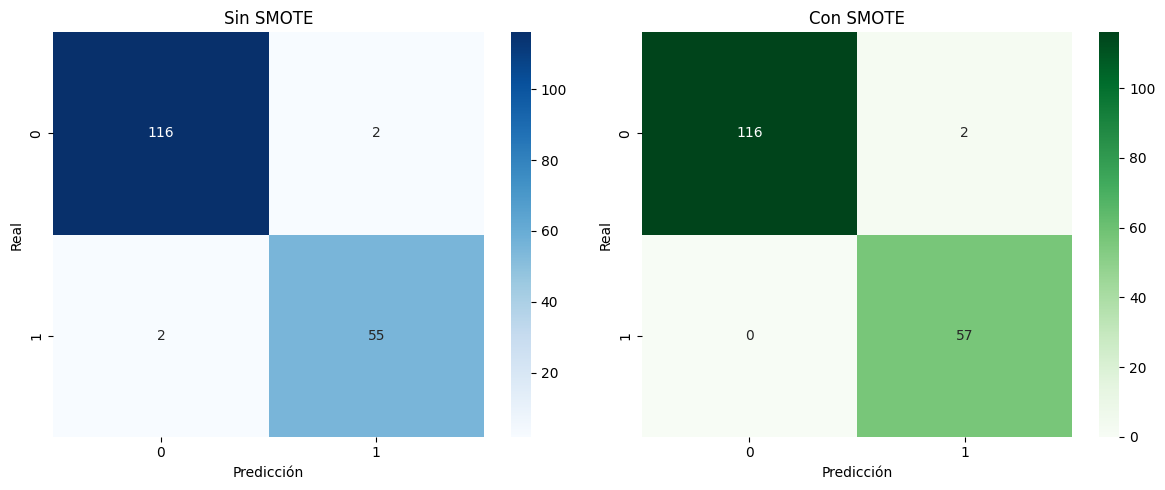

In [14]:
# Visualización de matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_orig), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Sin SMOTE")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

sns.heatmap(confusion_matrix(y_test, y_pred_smote), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Con SMOTE")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()
